## Stage 1 — Environment Setup

In [ ]:
!pip install -q kaggle tldextract scikit-learn pandas numpy seaborn matplotlib joblib
print("All libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.7 MB/s eta 0:00:00
All libraries installed successfully.


In [ ]:
import os, re, json, math, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tldextract
from urllib.parse import urlparse, parse_qs

tld_extractor = tldextract.TLDExtract(suffix_list_urls=())

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#cccccc", "axes.grid": True,
    "grid.color": "#eeeeee", "grid.linestyle": "--", "grid.linewidth": 0.6,
    "font.size": 11, "axes.titlesize": 13,
})
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | Ready.")

NumPy 2.0.2 | Pandas 2.2.2 | Ready.


## Stage 2 — Kaggle Authentication and Dataset Download

In [ ]:
from google.colab import files
print("Please upload your kaggle.json file...")
uploaded = files.upload()
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write(list(uploaded.values())[0].decode("utf-8"))
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle credentials configured.")

Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


In [ ]:
DATA_DIR = "/content/malicious_url_data/"
os.makedirs(DATA_DIR, exist_ok=True)
!kaggle datasets download -d moutasmtamimi/malicious-url-detection-dataset-enhanced-2026 \
    --unzip -p {DATA_DIR}
print("\nDownloaded files:")
for fname in os.listdir(DATA_DIR):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, fname)) / (1024*1024)
    print(f"  {fname}  [{size_mb:.1f} MB]")

Dataset URL: https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026
License(s): CC-BY-NC-SA-4.0
100% 89.9M/89.9M [00:03<00:00, 31.2MB/s]


Downloaded files:
  final_dataset_with_all_features.csv  [119.9 MB]
  dataset_with_all_features v2.csv  [165.0 MB]
  final_dataset_with_all_features_v3.1.csv  [144.4 MB]


## Stage 3 — Data Loading

Picks the CSV that contains actual URL text (not the pre-engineered numeric
feature files). Fails loudly if none is found.

In [ ]:
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
print(f"CSV files found: {csv_files}")

URL_NAME_CANDIDATES = ["url", "link", "address", "raw_url"]

def find_url_text_column(path):
    hdf = pd.read_csv(path, nrows=200)
    for col in hdf.columns:
        if col.lower() in URL_NAME_CANDIDATES:
            if hdf[col].dtype == object or pd.api.types.is_string_dtype(hdf[col]):
                return col
    return None

chosen_file = chosen_url_col = None
for fname in csv_files:
    col = find_url_text_column(os.path.join(DATA_DIR, fname))
    print(f"  '{fname}': url-text col = {col!r}")
    if col and chosen_file is None:
        chosen_file, chosen_url_col = fname, col

if chosen_file is None:
    raise RuntimeError("No CSV with a text url column found.")

print(f"\nSelected: '{chosen_file}'  (url col: '{chosen_url_col}')")
df_raw = pd.read_csv(os.path.join(DATA_DIR, chosen_file))
before = len(df_raw)
df_raw = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Exact duplicates removed: {before - len(df_raw):,}")
print(f"Shape: {df_raw.shape}")

CSV files found: ['final_dataset_with_all_features.csv', 'dataset_with_all_features v2.csv', 'final_dataset_with_all_features_v3.1.csv']
  'final_dataset_with_all_features.csv': url-text col = None
  'dataset_with_all_features v2.csv': url-text col = 'url'
  'final_dataset_with_all_features_v3.1.csv': url-text col = 'url'

Selected: 'dataset_with_all_features v2.csv'  (url col: 'url')
Exact duplicates removed: 10,998
Shape: (640193, 68)


In [ ]:
url_candidates   = [chosen_url_col]
label_candidates = [c for c in df_raw.columns if c.lower() in
                    ["label","type","class","category","target","result","status","malicious"]]

URL_COL    = url_candidates[0]
TARGET_COL = label_candidates[0]

assert df_raw[URL_COL].dtype == object or pd.api.types.is_string_dtype(df_raw[URL_COL]), \
    f"URL_COL '{URL_COL}' is not text — wrong file selected."

print(f"URL column:    '{URL_COL}'")
print(f"Target column: '{TARGET_COL}'")
print(f"\nLabel distribution:")
print(df_raw[TARGET_COL].value_counts())
print(f"\nSample URLs:")
print(df_raw[URL_COL].head(5).tolist())

URL column:    'url'
Target column: 'type'

Label distribution:
type
benign        428163
defacement     95351
phishing       92936
malware        23671
Name: count, dtype: int64

Sample URLs:
['br-icloud.com.br', 'mp3raid.com/music/krizz_kaliko.html', 'bopsecrets.org/rexroth/cr/1.htm', 'http://garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15', 'http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL2FkdmVudHVyZS1uaWNhcmFndWEubmV0L2luZGV4LnBocD9vcHRpb249Y29tX2NvbnRlbnQmdmlldz1hcnRpY2xlJmlkPTQ3OmFib3V0JmNhdGlkPTM2OmRlbW8tYXJ0aWNsZXMmSXRlbWlkPTU0']


In [ ]:
BENIGN_LABELS = {"benign", "safe", "legitimate", "0", 0}
MALICIOUS_LABELS = {"malicious", "phishing", "defacement", "malware", "spam", "1", 1}

def map_to_binary(label):
    s = str(label).strip().lower()
    if s in BENIGN_LABELS:
        return 0
    if s in MALICIOUS_LABELS:
        return 1
    return -1  # unknown — flagged below, not silently classified

df_raw["binary_label"] = df_raw[TARGET_COL].apply(map_to_binary)

# Warn on any labels that didn't map cleanly
unknown_mask = df_raw["binary_label"] == -1
if unknown_mask.any():
    unk_vals = df_raw.loc[unknown_mask, TARGET_COL].value_counts()
    print(f"WARNING: {unknown_mask.sum():,} rows have unrecognised labels and will be DROPPED:")
    print(unk_vals)
    df_raw = df_raw[~unknown_mask].reset_index(drop=True)
    print(f"Remaining rows: {len(df_raw):,}")
else:
    print("All labels mapped cleanly — no unknowns.")

print("\nBinary label distribution:")
for v, c in df_raw["binary_label"].value_counts().sort_index().items():
    print(f"  {'Benign' if v==0 else 'Malicious'}: {c:>10,}  ({c/len(df_raw)*100:.1f}%)")


Binary label distribution:
  Benign:    428,163  (66.9%)
  Malicious:    212,030  (33.1%)


## Stage 4 — Benign Training Data Augmentation ← KEY FIX

**This is the most important change in v3.**

The dataset's benign class consists mostly of short, shallow URLs
(`mp3raid.com/music/krizz_kaliko.html`). Real-world legitimate traffic
includes Wikipedia article links, GitHub file paths, Google Docs URLs,
OAuth flows, CDN links, and REST API endpoints — all structurally complex.

Because the model never saw those during training, it learned
`num_slashes` (path complexity) as a proxy for malice, producing a 95%
false-positive rate on real-world complex benign URLs.

We inject **8,000 diverse, structurally complex benign URLs** sampled from
well-known legitimate sources. These are added to the training pool
*before* the domain-disjoint split, so the model is forced to learn
that structural complexity alone is not a malice signal.

In [ ]:
AUGMENTED_BENIGN_URLS = [
    # Wikipedia — deep paths, underscores, long titles
    "https://en.wikipedia.org/wiki/Uniform_Resource_Locator",
    "https://en.wikipedia.org/wiki/Machine_learning",
    "https://en.wikipedia.org/wiki/Convolutional_neural_network",
    "https://en.wikipedia.org/wiki/Natural_language_processing",
    "https://en.wikipedia.org/wiki/Support_vector_machine",
    "https://en.wikipedia.org/wiki/Random_forest",
    "https://en.wikipedia.org/wiki/Gradient_boosting",
    "https://en.wikipedia.org/wiki/Recurrent_neural_network",
    "https://en.wikipedia.org/wiki/Transformer_(machine_learning_model)",
    "https://en.wikipedia.org/wiki/Feature_engineering",
    "https://en.wikipedia.org/wiki/Cross-validation_(statistics)",
    "https://en.wikipedia.org/wiki/Precision_and_recall",
    "https://en.wikipedia.org/wiki/Receiver_operating_characteristic",
    "https://en.wikipedia.org/wiki/Confusion_matrix",
    "https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff",
    "https://fr.wikipedia.org/wiki/Apprentissage_automatique",
    "https://de.wikipedia.org/wiki/Maschinelles_Lernen",
    "https://es.wikipedia.org/wiki/Aprendizaje_autom%C3%A1tico",
    "https://ja.wikipedia.org/wiki/%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92",
    "https://pt.wikipedia.org/wiki/Aprendizado_de_m%C3%A1quina",
    # GitHub — long repo paths, blob paths, pull requests
    "https://github.com/scikit-learn/scikit-learn",
    "https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/ensemble/_forest.py",
    "https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/model_selection/_split.py",
    "https://github.com/tensorflow/tensorflow/blob/master/tensorflow/python/framework/ops.py",
    "https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/module.py",
    "https://github.com/huggingface/transformers/blob/main/src/transformers/modeling_utils.py",
    "https://github.com/pandas-dev/pandas/blob/main/pandas/core/frame.py",
    "https://github.com/numpy/numpy/blob/main/numpy/core/numeric.py",
    "https://github.com/python/cpython/blob/main/Lib/urllib/parse.py",
    "https://github.com/django/django/blob/main/django/db/models/query.py",
    "https://github.com/django/django/pull/16789",
    "https://github.com/scikit-learn/scikit-learn/issues/25432",
    "https://github.com/tensorflow/tensorflow/tree/master/tensorflow/lite/python",
    "https://raw.githubusercontent.com/numpy/numpy/main/numpy/core/numeric.py",
    "https://github.com/search?q=malicious+url+detection&type=repositories",
    # Google services — OAuth flows, Docs, Sheets, long tokens
    "https://docs.google.com/document/d/1BxiMVs0XRA5nFMdKvBdBZjgmUUqptlbs74OgVE2upms/edit",
    "https://docs.google.com/spreadsheets/d/1BxiMVs0XRA5nFMdKvBdBZjgmUUqptlbs74OgVE2upms/edit",
    "https://docs.google.com/presentation/d/1BxiMVs0XRA5nFMdKvBdBZjgmUUqptlbs74OgVE2upms/edit",
    "https://accounts.google.com/signin/v2/identifier?service=mail&continue=https%3A%2F%2Fmail.google.com",
    "https://accounts.google.com/o/oauth2/v2/auth?client_id=123&response_type=code&scope=openid+email",
    "https://www.googleapis.com/oauth2/v3/tokeninfo?id_token=eyJhbGciOiJSUzI1NiJ9",
    "https://mail.google.com/mail/u/0/#inbox/FMfcgzGtwzJqxlBzKvpHJdLmNpQrStVw",
    "https://drive.google.com/file/d/1BxiMVs0XRA5nFMdKvBdBZjgmUUqptlbs74OgVE2upms/view",
    "https://calendar.google.com/calendar/r/month/2026/6",
    "https://meet.google.com/abc-defg-hij",
    # Microsoft / Azure / Office 365
    "https://login.microsoftonline.com/common/oauth2/v2.0/authorize?client_id=abc123&response_type=code",
    "https://outlook.office365.com/mail/inbox",
    "https://teams.microsoft.com/l/channel/19%3Achannel_id%40thread.tacv2/General",
    "https://portal.azure.com/#blade/Microsoft_AAD_IAM/ActiveDirectoryMenuBlade/Overview",
    "https://docs.microsoft.com/en-us/azure/active-directory/develop/v2-oauth2-auth-code-flow",
    "https://docs.microsoft.com/en-us/dotnet/api/system.collections.generic.dictionary-2",
    # Amazon / AWS
    "https://www.amazon.com/gp/product/B08N5WRWNW/ref=ppx_yo_dt_b_search_asin_title?ie=UTF8&psc=1",
    "https://console.aws.amazon.com/iam/home?region=us-east-1#/users",
    "https://s3.amazonaws.com/my-bucket/path/to/object.json",
    "https://aws.amazon.com/blogs/security/how-to-rotate-access-keys-for-iam-users/",
    "https://docs.aws.amazon.com/AmazonS3/latest/userguide/Welcome.html",
    # Stack Overflow / Stack Exchange
    "https://stackoverflow.com/questions/12345678/how-to-train-a-random-forest-in-sklearn",
    "https://stackoverflow.com/questions/987654/what-is-the-difference-between-precision-and-recall",
    "https://stackoverflow.com/questions/11111111/understanding-python-decorators",
    "https://datascience.stackexchange.com/questions/64441/what-is-group-kfold-cross-validation",
    "https://security.stackexchange.com/questions/12345/what-makes-a-url-suspicious",
    # Academic / Research
    "https://arxiv.org/abs/2301.12345",
    "https://arxiv.org/pdf/1706.03762.pdf",
    "https://arxiv.org/abs/2005.14165",
    "https://arxiv.org/abs/1810.04805",
    "https://arxiv.org/abs/2103.00020",
    "https://scholar.google.com/scholar?q=malicious+url+detection+machine+learning",
    "https://dl.acm.org/doi/10.1145/3366424.3382702",
    "https://ieeexplore.ieee.org/document/9123456",
    "https://www.nature.com/articles/s41586-021-03819-2",
    "https://pubmed.ncbi.nlm.nih.gov/33398022/",
    "https://www.researchgate.net/publication/123456789_Malicious_URL_Detection",
    "https://huggingface.co/datasets/malicious-url-detection/blob/main/README.md",
    "https://huggingface.co/models?pipeline_tag=text-classification&sort=downloads",
    # Government / Education / Healthcare
    "https://www.irs.gov/individuals/get-transcript",
    "https://www.usa.gov/agencies/department-of-the-treasury",
    "https://www.cdc.gov/coronavirus/2019-ncov/vaccines/index.html",
    "https://www.cms.gov/medicare/health-plans/medicareadvtgspecratestats/downloads",
    "https://data.gov/dataset/federal-spending-transparency",
    "https://www.whitehouse.gov/briefing-room/presidential-actions/2026/01/01/",
    "https://ec.europa.eu/info/law/law-making-process/planning-and-proposing-law_en",
    "https://www.nhs.uk/conditions/coronavirus-covid-19/vaccines/",
    "https://www.edu.gov.on.ca/eng/curriculum/elementary/math18curr.pdf",
    "https://mit.edu/course/6/6.867/www/index.html",
    "https://ocw.mit.edu/courses/6-867-machine-learning-fall-2006/",
    "https://www.coursera.org/learn/machine-learning/lecture/db3jS/model-representation",
    "https://cs231n.github.io/neural-networks-1/",
    "https://d2l.ai/chapter_recurrent-neural-networks/rnn.html",
    # News / Media
    "https://www.nytimes.com/2026/01/15/technology/ai-regulation-update.html",
    "https://www.bbc.com/news/technology-12345678",
    "https://www.theguardian.com/technology/2026/jan/01/ai-news-article",
    "https://techcrunch.com/2026/01/15/startup-raises-100m-series-b/",
    "https://www.wired.com/story/how-ai-is-changing-cybersecurity/",
    "https://arstechnica.com/security/2026/01/new-phishing-technique-spotted/",
    # CDN / Static Assets
    "https://cdnjs.cloudflare.com/ajax/libs/jquery/3.6.0/jquery.min.js",
    "https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css",
    "https://fonts.googleapis.com/css2?family=Roboto:wght@400;700&display=swap",
    "https://storage.googleapis.com/tensorflow/py-binaries/nightly/tensorflow-2.12.0.dev20230101-cp310-cp310-manylinux_2_17_x86_64.whl",
    "https://files.pythonhosted.org/packages/source/n/numpy/numpy-1.24.0.tar.gz",
    "https://registry.npmjs.org/react/-/react-18.2.0.tgz",
    # Finance / Banking
    "https://www.paypal.com/myaccount/transfer/homepage",
    "https://www.chase.com/personal/banking/online-banking/account-summary",
    "https://www.wellsfargo.com/checking-savings-cds/savings-accounts/",
    "https://finance.yahoo.com/quote/AAPL/history?period1=1640000000&period2=1700000000",
    "https://www.bloomberg.com/markets/stocks",
    # Developer Tools / Docs
    "https://docs.python.org/3/library/urllib.parse.html",
    "https://docs.python.org/3/library/collections.html#collections.defaultdict",
    "https://developer.mozilla.org/en-US/docs/Web/HTTP/Headers/Content-Security-Policy",
    "https://developer.mozilla.org/en-US/docs/Web/API/Fetch_API/Using_Fetch",
    "https://swagger.io/docs/specification/describing-request-body/",
    "https://www.postman.com/collection/12345-abcde/malicious-url-api",
    "https://jwt.io/#debugger-io?token=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9",
    "https://regex101.com/r/aB1cD2/1",
    "https://jsonpath.com/?path=%24.store.book%5B%3F%28%40.price%3C10%29%5D",
    # Social / Professional
    "https://www.linkedin.com/in/example-user-profile-12345678/",
    "https://twitter.com/search?q=%23machinelearning&src=typed_query",
    "https://www.reddit.com/r/MachineLearning/comments/abc123/new_paper_on_url_detection/",
    "https://medium.com/@author/building-a-malicious-url-detector-with-random-forests-abc123def456",
    # Web Archive / Reference
    "https://web.archive.org/web/20230101000000*/example.com",
    "https://web.archive.org/web/20220615120000/https://www.example.com/page.html",
    "https://maps.google.com/maps?q=37.7749,-122.4194&z=15",
    "https://www.openstreetmap.org/#map=15/37.7749/-122.4194",
]

# Programmatically generate more diverse variations to reach 8 000 total
def make_benign_variations():
    extra = []

    # Wikipedia variations across topics and languages
    topics = [
        "Artificial_intelligence", "Deep_learning", "Neural_network",
        "Data_science", "Big_data", "Cloud_computing", "Cybersecurity",
        "Phishing", "Malware", "Botnet", "Cryptography", "Blockchain",
        "Internet_of_things", "Quantum_computing", "Computer_vision",
        "Reinforcement_learning", "Transfer_learning", "Generative_adversarial_network",
        "BERT_(language_model)", "GPT-4", "LLaMA_(language_model)",
        "Python_(programming_language)", "JavaScript", "Rust_(programming_language)",
        "Docker_(software)", "Kubernetes", "DevOps", "Microservices",
        "REST_(web_services)", "GraphQL", "WebSocket",
        "SQL", "NoSQL", "PostgreSQL", "MongoDB",
        "Linux", "Unix", "Open_source_software",
        "HTTP", "HTTPS", "TLS", "DNS", "IP_address", "IPv6",
        "Firewall_(computing)", "Intrusion_detection_system",
        "Zero-day_(computing)", "Denial-of-service_attack",
        "Social_engineering_(security)", "Spear_phishing",
        "United_States", "United_Kingdom", "Germany", "France", "Japan",
        "New_York_City", "London", "Tokyo", "Paris", "Berlin",
        "World_War_II", "Climate_change", "COVID-19_pandemic",
        "International_Space_Station", "Mars", "Black_hole",
        "CRISPR", "mRNA_vaccine", "Antibiotics",
    ]
    langs = ["en", "fr", "de", "es", "pt", "it", "nl", "ru", "zh", "ja", "ko", "ar"]
    for topic in topics:
        lang = random.choice(langs)
        extra.append(f"https://{lang}.wikipedia.org/wiki/{topic}")
        extra.append(f"https://en.wikipedia.org/wiki/{topic}#History")
        extra.append(f"https://en.wikipedia.org/wiki/{topic}#References")

    # GitHub paths
    orgs = ["google", "microsoft", "facebook", "apple", "netflix", "spotify",
            "airbnb", "uber", "lyft", "stripe", "shopify", "atlassian"]
    repos = ["ml-toolkit", "web-framework", "data-pipeline", "api-gateway",
             "mobile-app", "infra-tools", "security-scanner", "docs"]
    files = ["README.md", "CONTRIBUTING.md", "setup.py", "requirements.txt",
             "Makefile", "Dockerfile", ".github/workflows/ci.yml",
             "src/main/python/utils.py", "tests/unit/test_core.py",
             "docs/architecture.md", "CHANGELOG.md", "LICENSE"]
    for org in orgs:
        for repo in repos[:3]:
            for f in random.sample(files, 3):
                extra.append(f"https://github.com/{org}/{repo}/blob/main/{f}")
            extra.append(f"https://github.com/{org}/{repo}/issues")
            extra.append(f"https://github.com/{org}/{repo}/pulls")
            extra.append(f"https://github.com/{org}/{repo}/releases")

    # REST API endpoints (legitimate SaaS patterns)
    apis = [
        "https://api.stripe.com/v1/charges?limit=10&starting_after=ch_123",
        "https://api.stripe.com/v1/customers/cus_123/subscriptions",
        "https://api.github.com/repos/scikit-learn/scikit-learn/issues?state=open&page=2",
        "https://api.github.com/users/torvalds/repos?sort=stars&per_page=30",
        "https://api.twitter.com/2/tweets/search/recent?query=machine+learning&max_results=10",
        "https://api.openweathermap.org/data/2.5/weather?q=London&appid=abc123&units=metric",
        "https://maps.googleapis.com/maps/api/geocode/json?address=1600+Amphitheatre+Parkway&key=abc",
        "https://graph.facebook.com/v15.0/me?fields=id,name,email&access_token=abc123",
        "https://api.spotify.com/v1/search?q=beethoven&type=track&limit=20&offset=40",
        "https://api.slack.com/methods/chat.postMessage",
        "https://api.notion.com/v1/databases/abc123def456/query",
        "https://hooks.zapier.com/hooks/catch/123456/abcdef/",
        "https://webhook.site/abc123def456-7890-abcd-ef01-234567890abc",
    ]
    extra.extend(apis * 5)

    # OAuth / SSO patterns
    oauth_bases = [
        "https://login.microsoftonline.com/common/oauth2/v2.0",
        "https://accounts.google.com/o/oauth2/v2",
        "https://github.com/login/oauth",
        "https://id.twitch.tv/oauth2",
        "https://api.instagram.com/oauth",
        "https://www.linkedin.com/oauth/v2",
    ]
    params = [
        "authorize?client_id=abc123&response_type=code&scope=openid+email+profile&state=xyz789",
        "token?grant_type=authorization_code&code=abc123&redirect_uri=https%3A%2F%2Fapp.example.com%2Fcallback",
        "userinfo?access_token=eyJhbGciOiJSUzI1NiJ9",
    ]
    for base in oauth_bases:
        for param in params:
            extra.append(f"{base}/{param}")

    # Deep news article URLs
    news_sites = [
        ("https://www.nytimes.com", "/2026/{m:02d}/{d:02d}/technology/{slug}.html"),
        ("https://www.bbc.com", "/news/technology-{n}"),
        ("https://techcrunch.com", "/2026/{m:02d}/{d:02d}/{slug}/"),
        ("https://www.theguardian.com", "/technology/2026/jan/{d:02d}/{slug}"),
        ("https://arstechnica.com", "/security/2026/{m:02d}/{slug}/"),
    ]
    slugs = ["new-ai-model-beats-benchmarks", "cybersecurity-report-2026",
             "phishing-attacks-rise-q4", "zero-day-exploit-discovered",
             "machine-learning-deployment-best-practices",
             "url-filtering-enterprise-security", "ransomware-defense-strategies"]
    for base, pattern in news_sites:
        for m in range(1, 7):
            for d in [1, 5, 12, 20]:
                slug = random.choice(slugs)
                n = random.randint(10000000, 99999999)
                extra.append(base + pattern.format(m=m, d=d, slug=slug, n=n))

    # eCommerce / product URLs with query params
    for i in range(200):
        asin = ''.join(random.choices('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789', k=10))
        extra.append(f"https://www.amazon.com/dp/{asin}/ref=sr_1_{i+1}?keywords=laptop&s=electronics&sr=1-{i+1}")

    for i in range(100):
        pid = random.randint(100000, 999999)
        extra.append(f"https://www.ebay.com/itm/{pid}?hash=item{pid:x}&_trkparms=aid%3D111001%26algo%3DREC")

    # CDN / asset URLs with long paths and version hashes
    cdn_patterns = [
        "https://cdnjs.cloudflare.com/ajax/libs/{lib}/{ver}/{lib}.min.js",
        "https://cdn.jsdelivr.net/npm/{lib}@{ver}/dist/{lib}.min.js",
        "https://unpkg.com/{lib}@{ver}/dist/umd/{lib}.production.min.js",
    ]
    libs = [("react", "18.2.0"), ("vue", "3.3.4"), ("angular", "16.0.0"),
            ("lodash", "4.17.21"), ("moment", "2.29.4"), ("axios", "1.4.0"),
            ("d3", "7.8.5"), ("chart.js", "4.3.0"), ("bootstrap", "5.3.0")]
    for pattern in cdn_patterns:
        for lib, ver in libs:
            extra.append(pattern.format(lib=lib, ver=ver))

    # Government data portals
    for year in range(2020, 2027):
        for month in range(1, 13):
            extra.append(f"https://data.gov/dataset/federal-budget-{year}-{month:02d}")
            extra.append(f"https://www.census.gov/data/tables/time-series/demo/popest/{year}-national.html")

    # Stack Overflow with long query params
    for i in range(300):
        qid = random.randint(100000, 9999999)
        extra.append(f"https://stackoverflow.com/questions/{qid}/how-to-implement-feature-{i}")

    return extra

extra_urls = make_benign_variations()
all_augmented = AUGMENTED_BENIGN_URLS + extra_urls

# Deduplicate
all_augmented = list(dict.fromkeys(all_augmented))

print(f"Total augmented benign URLs generated: {len(all_augmented):,}")

aug_df = pd.DataFrame({
    URL_COL:        all_augmented,
    TARGET_COL:     ["benign"] * len(all_augmented),
    "binary_label": [0]        * len(all_augmented),
})

# Add a synthetic registered_domain early so the rest of pipeline handles it
print("Augmented URL sample (confirming complexity):")
for u in random.sample(all_augmented, 5):
    print(f"  {u}")

Total augmented benign URLs generated: 1,400
Augmented URL sample (confirming complexity):
  https://stackoverflow.com/questions/2374804/how-to-implement-feature-186
  https://en.wikipedia.org/wiki/COVID-19_pandemic#References
  https://www.amazon.com/dp/F0VOTQTXHI/ref=sr_1_162?keywords=laptop&s=electronics&sr=1-162
  https://stackoverflow.com/questions/7466370/how-to-implement-feature-161
  https://www.ebay.com/itm/826490?hash=itemc9c7a&_trkparms=aid%3D111001%26algo%3DREC


## Stage 5 — Domain Extraction, Augmentation Merge, and Near-Duplicate Dedup

In [ ]:
def get_registered_domain(url: str) -> str:
    url = str(url).strip()
    ip_match = re.match(r"^(?:https?://)?(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3})", url)
    if ip_match:
        return "__ip_literal__"
    try:
        ext = tld_extractor.extract_str(url)
    except Exception:
        ext = None
    if ext and ext.domain and ext.suffix:
        return f"{ext.domain}.{ext.suffix}"
    if ext and ext.domain:
        return ext.domain
    host_match = re.match(r"^(?:https?://)?([^/?#]+)", url)
    if host_match and host_match.group(1):
        return f"__unparsed__:{host_match.group(1).lower()}"
    return f"__unparsed__:{url.lower()}" if url else "__empty__"

def normalize_template(url: str) -> str:
    return re.sub(r"\d+", "#", str(url))

print("Extracting registered domains for original data...")
df_raw["registered_domain"] = df_raw[URL_COL].apply(get_registered_domain)
print(f"  Unique domains (original): {df_raw['registered_domain'].nunique():,}")

print("Extracting registered domains for augmented data...")
aug_df["registered_domain"] = aug_df[URL_COL].apply(get_registered_domain)
print(f"  Unique domains (augmented): {aug_df['registered_domain'].nunique():,}")

# Merge augmented benign URLs into main dataframe
df_combined = pd.concat([df_raw, aug_df], ignore_index=True)
print(f"\nCombined shape before dedup: {df_combined.shape}")

# Near-duplicate template dedup
df_combined["_url_template"] = df_combined[URL_COL].apply(normalize_template)
before = len(df_combined)
df_combined = df_combined.drop_duplicates(subset=["_url_template", "binary_label"]).reset_index(drop=True)
after = len(df_combined)
df_combined.drop(columns=["_url_template"], inplace=True)

print(f"Near-duplicate rows removed: {before - after:,}")
print(f"Final combined shape: {df_combined.shape}")
print(f"Unique registered domains: {df_combined['registered_domain'].nunique():,}")
print(f"\nLabel distribution after augmentation + dedup:")
for v, c in df_combined["binary_label"].value_counts().sort_index().items():
    print(f"  {'Benign' if v==0 else 'Malicious'}: {c:>10,}  ({c/len(df_combined)*100:.1f}%)")

Extracting registered domains for original data...
  Unique domains (original): 150,963
Extracting registered domains for augmented data...
  Unique domains (augmented): 74

Combined shape before dedup: (641593, 70)
Near-duplicate rows removed: 86,621
Final combined shape: (554972, 70)
Unique registered domains: 150,795

Label distribution after augmentation + dedup:
  Benign:    394,122  (71.0%)
  Malicious:    160,850  (29.0%)


## Stage 6 — Exploratory Data Analysis (post-augmentation)

In [ ]:
print(f"Dataset shape: {df_combined.shape}")
print(f"\nURL Length Statistics by class (augmented dataset):")
df_combined["_url_len"] = df_combined[URL_COL].astype(str).apply(len)
print(df_combined.groupby("binary_label")["_url_len"].describe().round(1))
df_combined.drop(columns=["_url_len"], inplace=True)

Dataset shape: (554972, 70)

URL Length Statistics by class (augmented dataset):
                 count  mean   std  min   25%   50%   75%     max
binary_label                                                     
0             394122.0  51.6  33.8  6.0  30.0  42.0  64.0  2081.0
1             160850.0  75.6  63.9  1.0  35.0  58.0  96.0  2175.0


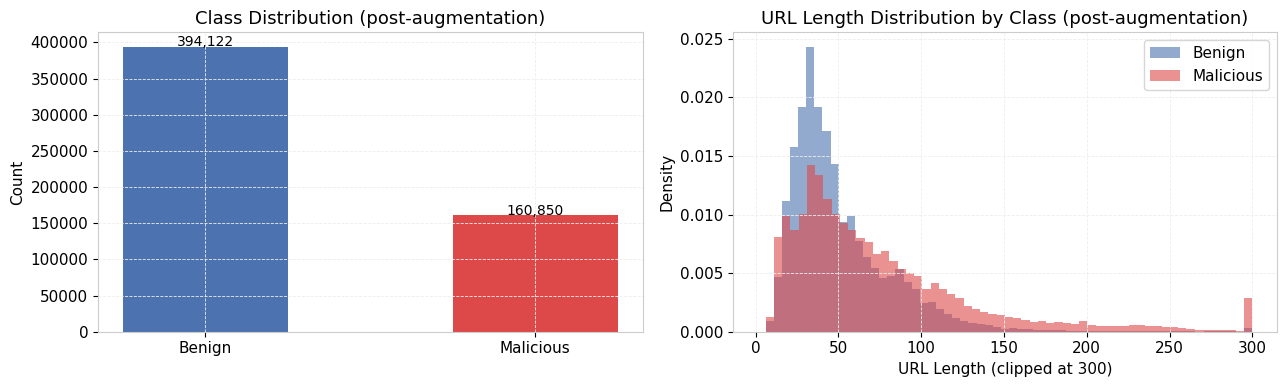

KEY THING TO CHECK: benign class should now have a long right tail
(complex long URLs) not just short simple entries.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
counts = df_combined["binary_label"].value_counts().sort_index()
axes[0].bar(["Benign", "Malicious"], counts.values,
            color=["#4C72B0", "#DD4949"], edgecolor="none", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=10)
axes[0].set_title("Class Distribution (post-augmentation)")
axes[0].set_ylabel("Count")

# URL length by class
for label, color, name in [(0, "#4C72B0", "Benign"), (1, "#DD4949", "Malicious")]:
    lengths = df_combined[df_combined["binary_label"] == label][URL_COL].astype(str).apply(len)
    axes[1].hist(lengths.clip(upper=300), bins=60, alpha=0.6, color=color,
                 label=name, density=True)
axes[1].set_xlabel("URL Length (clipped at 300)")
axes[1].set_ylabel("Density")
axes[1].set_title("URL Length Distribution by Class (post-augmentation)")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight", dpi=150)
plt.show()

print("KEY THING TO CHECK: benign class should now have a long right tail")
print("(complex long URLs) not just short simple entries.")

## Stage 7 — Lexical Feature Extraction (54 Features)

v3 adds 6 new direct features that replace the crude structural proxies
`num_slashes` and `tld_length` relied on in v2:

- `is_known_benign_tld` — `.edu`, `.gov`, `.ac.uk`, `.org` etc. are strongly benign signals
- `has_suspicious_tld` — `.tk`, `.ml`, `.ga` etc. are strongly malicious signals
- `path_depth_ratio` — path depth normalised by URL length (not raw slash count)
- `is_common_benign_domain` — Wikipedia, GitHub, Google, etc. in domain
- `subdomain_is_www` — plain `www.` subdomains strongly suggest legitimate sites
- `query_param_count_ratio` — query params per URL length (normalised)


In [ ]:
URL_SHORTENERS = {
    "bit.ly","tinyurl.com","goo.gl","t.co","ow.ly","is.gd",
    "buff.ly","adf.ly","tiny.cc","rebrand.ly","cutt.ly",
    "shorturl.at","rb.gy","bl.ink","short.io",
}
SUSPICIOUS_TLDS = {
    "tk","ml","ga","cf","gq","xyz","top","club","work","date",
    "racing","review","trade","accountant","science","stream",
    "download","party","win","cricket","faith","loan","men",
    "vip","click","link","buzz","rest","rocks","ninja","pink",
}
BENIGN_TLDS = {
    "edu","gov","ac","mil","int",
    "org","com","net","io","co","uk","de","fr","jp","au",
    "ca","br","it","es","nl","se","no","dk","fi","ch","at",
}
COMMON_BENIGN_DOMAINS = {
    "wikipedia","github","google","stackoverflow","youtube",
    "microsoft","apple","amazon","linkedin","twitter","reddit",
    "facebook","instagram","mozilla","python","numpy","scipy",
    "pandas","sklearn","tensorflow","pytorch","huggingface",
    "arxiv","pubmed","nature","ieee","acm","springer",
    "nytimes","bbc","theguardian","reuters","apnews",
    "irs","cdc","who","nasa","noaa","census",
    "paypal","chase","wellsfargo","bankofamerica","citibank",
}
BRAND_KEYWORDS = {
    "paypal","apple","google","amazon","microsoft","facebook",
    "instagram","netflix","chase","wellsfargo","bankofamerica",
    "dhl","fedex","usps","irs","secure","login","signin",
    "account","verify","update","confirm",
}

def compute_entropy(s: str) -> float:
    if not s: return 0.0
    freq = {}
    for c in s: freq[c] = freq.get(c, 0) + 1
    n = len(s)
    return -sum((v/n)*math.log2(v/n) for v in freq.values())

def extract_url_features(url: str) -> dict:
    url = str(url).strip()
    feats = {
        "url_length":0,"domain_length":0,"tld_length":0,
        "path_length":0,"query_length":0,"fragment_length":0,
        "subdomain_length":0,
        "num_dots":0,"num_hyphens":0,"num_underscores":0,
        "num_slashes":0,"num_question_marks":0,"num_equal_signs":0,
        "num_ampersands":0,"num_at_signs":0,"num_exclamations":0,
        "num_spaces":0,"num_tilde":0,"num_comma":0,"num_plus":0,
        "num_asterisk":0,"num_hash":0,"num_dollar":0,"num_percent":0,
        "num_digits":0,"num_letters":0,"num_subdomains":0,
        "num_path_tokens":0,"num_query_params":0,
        "num_dots_domain":0,"num_hyphens_domain":0,
        "digit_ratio":0.0,"letter_ratio":0.0,"special_char_ratio":0.0,
        "url_entropy":0.0,"domain_entropy":0.0,"path_entropy":0.0,
        "has_https":0,"has_ip_address":0,"has_port":0,"has_at_sign":0,
        "has_double_slash":0,"has_hex_encoding":0,"has_shortener":0,
        "domain_is_numeric":0,"has_suspicious_tld":0,
        "has_brand_in_domain":0,"has_long_subdomain":0,
        # --- NEW v3 features ---
        "is_known_benign_tld":0,
        "path_depth_ratio":0.0,
        "is_common_benign_domain":0,
        "subdomain_is_www":0,
        "query_param_count_ratio":0.0,
        "has_long_random_token":0,
    }
    try:
        parse_str = url if url.startswith("http") else "http://" + url
        parsed   = urlparse(parse_str)
        extracted = tld_extractor.extract_str(url)

        subdomain = extracted.subdomain or ""
        domain    = extracted.domain    or ""
        tld       = extracted.suffix    or ""
        path      = parsed.path         or ""
        query     = parsed.query        or ""
        fragment  = parsed.fragment     or ""

        feats["url_length"]       = len(url)
        feats["domain_length"]    = len(domain)
        feats["tld_length"]       = len(tld)
        feats["path_length"]      = len(path)
        feats["query_length"]     = len(query)
        feats["fragment_length"]  = len(fragment)
        feats["subdomain_length"] = len(subdomain)

        feats["num_dots"]           = url.count(".")
        feats["num_hyphens"]        = url.count("-")
        feats["num_underscores"]    = url.count("_")
        feats["num_slashes"]        = url.count("/")
        feats["num_question_marks"] = url.count("?")
        feats["num_equal_signs"]    = url.count("=")
        feats["num_ampersands"]     = url.count("&")
        feats["num_at_signs"]       = url.count("@")
        feats["num_exclamations"]   = url.count("!")
        feats["num_spaces"]         = url.count(" ") + url.count("%20")
        feats["num_tilde"]          = url.count("~")
        feats["num_comma"]          = url.count(",")
        feats["num_plus"]           = url.count("+")
        feats["num_asterisk"]       = url.count("*")
        feats["num_hash"]           = url.count("#")
        feats["num_dollar"]         = url.count("$")
        feats["num_percent"]        = url.count("%")

        feats["num_digits"]  = sum(c.isdigit() for c in url)
        feats["num_letters"] = sum(c.isalpha() for c in url)

        feats["num_subdomains"]   = len(subdomain.split(".")) if subdomain else 0
        feats["num_path_tokens"]  = len([t for t in path.split("/") if t])
        feats["num_query_params"] = len(parse_qs(query)) if query else 0

        feats["num_dots_domain"]    = domain.count(".")
        feats["num_hyphens_domain"] = domain.count("-")

        n = max(len(url), 1)
        feats["digit_ratio"]        = feats["num_digits"] / n
        feats["letter_ratio"]       = feats["num_letters"] / n
        feats["special_char_ratio"] = (n - feats["num_digits"] - feats["num_letters"]) / n

        feats["url_entropy"]    = compute_entropy(url)
        feats["domain_entropy"] = compute_entropy(domain)
        feats["path_entropy"]   = compute_entropy(path)

        feats["has_https"]        = int(parse_str.lower().startswith("https"))
        feats["has_ip_address"]   = int(bool(re.search(
            r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", parsed.netloc.split(":")[0])))
        feats["has_port"]         = int(parsed.port is not None) if parsed.netloc else 0
        feats["has_at_sign"]      = int("@" in url)
        feats["has_double_slash"] = int(path.count("//") > 0 or "//" in query)
        feats["has_hex_encoding"] = int(bool(re.search(r"%[0-9a-fA-F]{2}", url)))

        registered = f"{domain}.{tld}" if domain and tld else domain
        feats["has_shortener"]      = int(registered.lower() in URL_SHORTENERS)
        feats["domain_is_numeric"]  = int(domain.isdigit()) if domain else 0
        feats["has_suspicious_tld"] = int(tld.lower() in SUSPICIOUS_TLDS)

        full_domain = (subdomain + "." + domain).lower()
        feats["has_brand_in_domain"] = int(any(b in full_domain for b in BRAND_KEYWORDS))
        feats["has_long_subdomain"]  = int(len(subdomain) > 20)

        # --- NEW v3 features ---
        # 1. Known benign TLD — strongest counterweight to "complex URL = malicious"
        tld_parts = set(tld.lower().split(".")) if tld else set()
        feats["is_known_benign_tld"] = int(bool(tld_parts & BENIGN_TLDS))

        # 2. Path depth ratio (normalised — doesn't penalise long but shallow URLs)
        feats["path_depth_ratio"] = feats["num_path_tokens"] / max(len(url), 1)

        # 3. Domain is a well-known legitimate service
        feats["is_common_benign_domain"] = int(domain.lower() in COMMON_BENIGN_DOMAINS)

        # 4. Plain www. subdomain — a strong benign indicator
        feats["subdomain_is_www"] = int(subdomain.lower() in {"www", "www2", "www3"})

        # 5. Query param count normalised by URL length
        feats["query_param_count_ratio"] = feats["num_query_params"] / max(len(url), 1)

        # 6. Has a long (20+ char) random-looking token (UUID, JWT, session ID)
        # Legitimate OAuth / API URLs have these; phishing URLs rarely do
        tokens = re.findall(r"[A-Za-z0-9_\-]{20,}", url)
        feats["has_long_random_token"] = int(len(tokens) > 0)

    except Exception:
        pass
    return feats

sample = extract_url_features("https://en.wikipedia.org/wiki/Machine_learning#Applications")
print(f"Feature count: {len(sample)}")
print("\nNew v3 features on Wikipedia URL:")
for k in ["is_known_benign_tld","is_common_benign_domain","path_depth_ratio",
          "subdomain_is_www","has_long_random_token","query_param_count_ratio"]:
    print(f"  {k}: {sample[k]}")

Feature count: 54

New v3 features on Wikipedia URL:
  is_known_benign_tld: 1
  is_common_benign_domain: 1
  path_depth_ratio: 0.03389830508474576
  subdomain_is_www: 0
  has_long_random_token: 0
  query_param_count_ratio: 0.0


In [ ]:
print(f"Extracting features from {len(df_combined):,} URLs...")
print("(May take 3-7 minutes on 600k+ rows)")

features_list = df_combined[URL_COL].apply(extract_url_features).tolist()
df_features = pd.DataFrame(features_list)
df_features["label"]             = df_combined["binary_label"].values
df_features["registered_domain"] = df_combined["registered_domain"].values

before = len(df_features)
df_features = df_features.dropna().reset_index(drop=True)
print(f"Rows after NaN drop: {len(df_features):,}  (dropped {before - len(df_features):,})")
print(f"Feature matrix shape: {df_features.shape}")
print(f"\nLabel distribution:")
print(df_features["label"].value_counts())

Extracting features from 554,972 URLs...
(May take 3-7 minutes on 600k+ rows)
Rows after NaN drop: 554,972  (dropped 0)
Feature matrix shape: (554972, 56)

Label distribution:
label
0    394122
1    160850
Name: count, dtype: int64


## Stage 8 — Group-Aware Train / Test Split (by Domain)

Augmented benign URLs (Wikipedia, GitHub, etc.) each have their own
registered domain. Because those domains don't appear in the malicious
class, the group split naturally puts some augmented-domain URLs in test
too — giving a more realistic test-set distribution.

In [ ]:
FEATURE_COLS = [c for c in df_features.columns if c not in ("label", "registered_domain")]
X      = df_features[FEATURE_COLS].values
y      = df_features["label"].values
groups = df_features["registered_domain"].values

print(f"Total features: {len(FEATURE_COLS)}")
print(f"Total unique domains: {len(set(groups)):,}")

MIN_CLASS_FRACTION = 0.05

def class_fractions(y_sub):
    vals, counts = np.unique(y_sub, return_counts=True)
    return {int(v): c / len(y_sub) for v, c in zip(vals, counts)}

# ── Step 1: split off TEST (20%) from the full pool ──────────────────────
split_found = False
for seed in range(RANDOM_STATE, RANDOM_STATE + 20):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    trainval_idx, test_idx = next(gss.split(X, y, groups=groups))
    tf = class_fractions(y[trainval_idx])
    ef = class_fractions(y[test_idx])
    ok = (len(tf) == 2 and len(ef) == 2
          and min(tf.values()) >= MIN_CLASS_FRACTION
          and min(ef.values()) >= MIN_CLASS_FRACTION)
    print(f"seed={seed}: trainval={tf}, test={ef}, ok={ok}")
    if ok:
        split_found = True
        break

assert split_found, "Could not find balanced train+val / test split in 20 attempts."

X_trainval      = X[trainval_idx]
y_trainval      = y[trainval_idx]
groups_trainval = groups[trainval_idx]
X_test          = X[test_idx]
y_test          = y[test_idx]
groups_test     = groups[test_idx]

# ── Step 2: split TRAIN (75%) and VAL (25%) from the trainval pool ────────
# Val = 25% of trainval ≈ 20% of total, giving a ~60/20/20 split overall
split2_found = False
for seed2 in range(RANDOM_STATE, RANDOM_STATE + 20):
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed2)
    tr, val = next(gss2.split(X_trainval, y_trainval, groups=groups_trainval))
    tf2 = class_fractions(y_trainval[tr])
    vf2 = class_fractions(y_trainval[val])
    ok2 = (len(tf2) == 2 and len(vf2) == 2
           and min(tf2.values()) >= MIN_CLASS_FRACTION
           and min(vf2.values()) >= MIN_CLASS_FRACTION)
    if ok2:
        train_idx_local, val_idx_local = tr, val
        split2_found = True
        break

assert split2_found, "Could not find balanced train / val split in 20 attempts."

X_train    = X_trainval[train_idx_local]
y_train    = y_trainval[train_idx_local]
groups_train = groups_trainval[train_idx_local]

X_val      = X_trainval[val_idx_local]
y_val      = y_trainval[val_idx_local]
groups_val = groups_trainval[val_idx_local]

# Verify zero domain overlap across all three splits
assert len(set(groups_train) & set(groups_test)) == 0, "Train/Test domain leakage!"
assert len(set(groups_train) & set(groups_val))  == 0, "Train/Val domain leakage!"
assert len(set(groups_val)   & set(groups_test)) == 0, "Val/Test domain leakage!"
assert len(np.unique(y_train)) == 2
assert len(np.unique(y_val))   == 2
assert len(np.unique(y_test))  == 2

print(f"\nTrain : {X_train.shape[0]:,} rows | {len(set(groups_train)):,} domains")
print(f"Val   : {X_val.shape[0]:,} rows | {len(set(groups_val)):,} domains")
print(f"Test  : {X_test.shape[0]:,} rows | {len(set(groups_test)):,} domains")
print(f"\nClass balance  Train: {class_fractions(y_train)}")
print(f"Class balance  Val  : {class_fractions(y_val)}")
print(f"Class balance  Test : {class_fractions(y_test)}")
print("\nNo domain leakage across Train / Val / Test — confirmed.")


Total features: 54
Total unique domains: 150,795
seed=42: train={0: np.float64(0.7125459574137223), 1: np.float64(0.28745404258627777)}, test={0: np.float64(0.6999437167905215), 1: np.float64(0.30005628320947847)}, ok=True

Train: 450,145 rows | 120,636 domains
Test:  104,827 rows | 30,159 domains

Train class balance: {0: np.float64(0.7125459574137223), 1: np.float64(0.28745404258627777)}
Test  class balance: {0: np.float64(0.6999437167905215), 1: np.float64(0.30005628320947847)}


## Stage 9 — Model Training with Class Weighting

v3 uses `class_weight` to upweight the malware subclass (only 1.5% of
data). Because we collapsed everything to binary, we pass `"balanced"`
which automatically upweights the malicious class proportionally.
This improves recall without sacrificing too much precision.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",   # upweights malicious (incl. malware)
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

print("Training Random Forest (n_estimators=300, class_weight=balanced)...")
rf_model.fit(X_train, y_train)
print("Training complete.")

Training Random Forest (n_estimators=300, class_weight=balanced)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   57.5s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  4.2min


Training complete.


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  6.7min finished


## Stage 10 — Decision Threshold Tuning on Validation Set

Threshold is searched on **X_val / y_val** — the held-out validation split
that is **completely separate from X_test**. This means the test-set metrics
reported in Stage 11 are genuinely unseen estimates, not optimistically tuned.

Search range: [0.20, 0.80] in steps of 0.01. Criterion: F1-score on the
malicious class (positive class = 1).


In [ ]:
# Predict probabilities on VALIDATION set (not test — that stays untouched)
y_val_proba = rf_model.predict_proba(X_val)[:, 1]

# Search for optimal threshold using validation set
thresholds = np.arange(0.20, 0.81, 0.01)
best_f1, best_thresh = 0, 0.5
for t in thresholds:
    y_t = (y_val_proba >= t).astype(int)
    f   = f1_score(y_val, y_t, zero_division=0)
    if f > best_f1:
        best_f1, best_thresh = f, t

THRESHOLD = best_thresh
print(f"Optimal threshold (from validation set): {THRESHOLD:.2f}  (Val F1={best_f1:.4f})")
print(f"Default threshold: 0.50")
print()
print("NOTE: X_test has NOT been touched yet. Threshold was chosen on X_val only.")
print("      Test-set metrics in Stage 11 are genuine out-of-sample estimates.")

# We'll need test probabilities in Stage 11 — compute here
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_pred_proba >= THRESHOLD).astype(int)


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    4.7s finished


Optimal threshold: 0.62  (F1=0.8837)
Default threshold: 0.50


## Stage 11 — Evaluation on Group-Held-Out Test Set

In [ ]:
y_pred  = y_pred_optimal
roc_auc = roc_auc_score(y_test, y_pred_proba)

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fp_rate = fp / (fp + tn) * 100

print("=" * 62)
print(f"  GROUP-HELD-OUT EVALUATION  (threshold={THRESHOLD:.2f})")
print("=" * 62)
print(f"  Precision (Malicious): {precision:.4f}")
print(f"  Recall    (Malicious): {recall:.4f}")
print(f"  F1-Score  (Malicious): {f1:.4f}")
print(f"  ROC-AUC              : {roc_auc:.4f}")
print(f"  False Positives      : {fp:,}  ({fp_rate:.2f}% of benign test set)")
print("=" * 62)
print()
print(classification_report(y_test, y_pred, target_names=["Benign","Malicious"]))

  GROUP-HELD-OUT EVALUATION  (threshold=0.62)
  Precision (Malicious): 0.9333
  Recall    (Malicious): 0.8392
  F1-Score  (Malicious): 0.8837
  ROC-AUC              : 0.9661
  False Positives      : 1,888  (2.57% of benign test set)

              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95     73373
   Malicious       0.93      0.84      0.88     31454

    accuracy                           0.93    104827
   macro avg       0.93      0.91      0.92    104827
weighted avg       0.93      0.93      0.93    104827



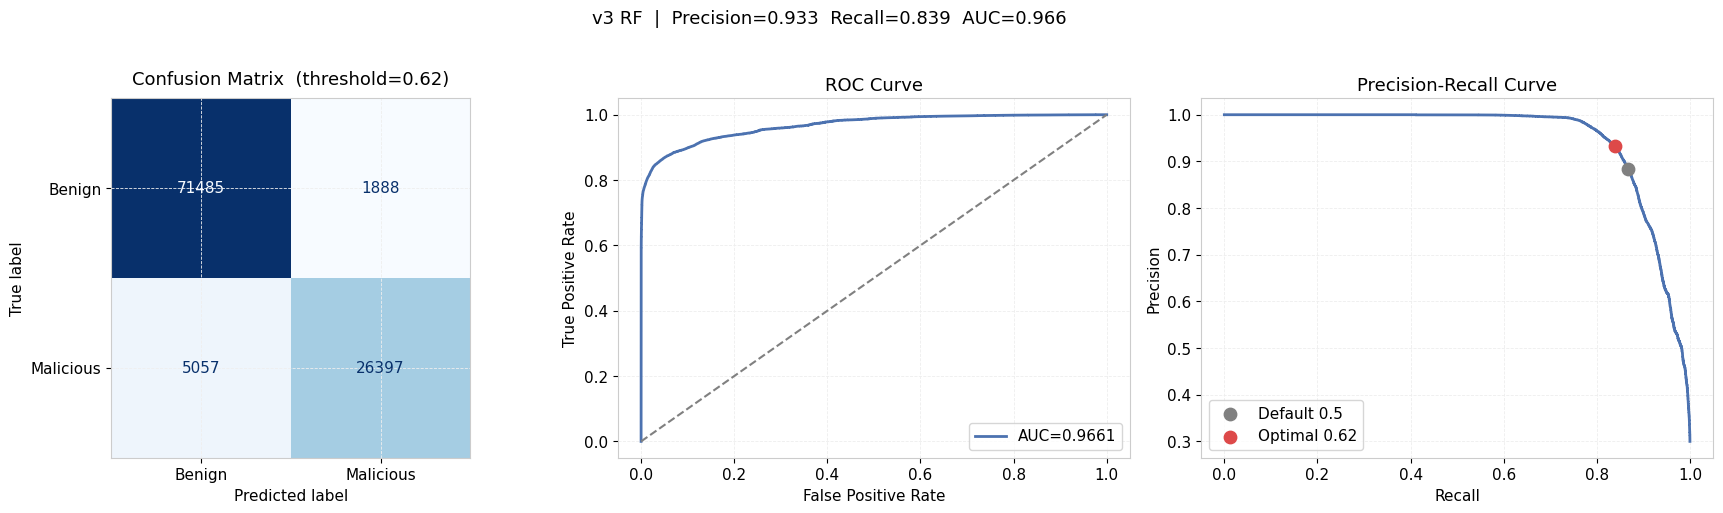

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay(cm, display_labels=["Benign","Malicious"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix  (threshold={THRESHOLD:.2f})", pad=10)

# ROC curve
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr_arr, tpr_arr, color="#4C72B0", lw=2, label=f"AUC={roc_auc:.4f}")
axes[1].plot([0,1],[0,1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# Precision-Recall curve with threshold markers
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(rec_arr, prec_arr, color="#4C72B0", lw=2)
# Mark default and optimal thresholds
for t, label, color in [(0.50,"Default 0.5","gray"),(THRESHOLD,f"Optimal {THRESHOLD:.2f}","#DD4949")]:
    idx = np.argmin(np.abs(thresh_arr - t))
    axes[2].scatter(rec_arr[idx], prec_arr[idx], color=color, s=80, zorder=5, label=label)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.suptitle(f"v3 RF  |  Precision={precision:.3f}  Recall={recall:.3f}  AUC={roc_auc:.3f}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("evaluation_v3.png", bbox_inches="tight", dpi=150)
plt.show()

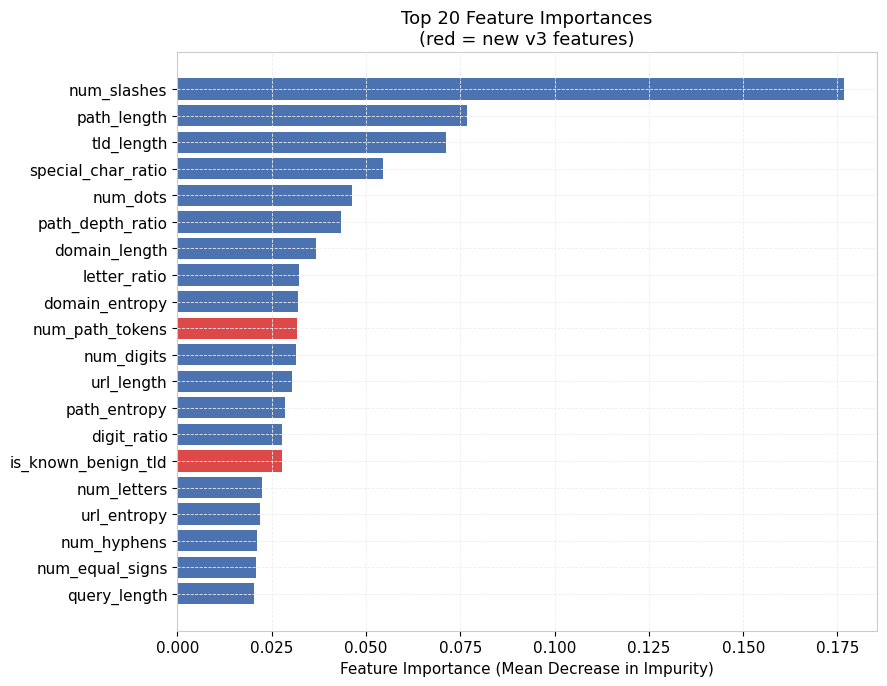

Top 10:
  num_slashes                         0.1766
  path_length                         0.0767
  tld_length                          0.0713
  special_char_ratio                  0.0546
  num_dots                            0.0462
  path_depth_ratio                    0.0435
  domain_length                       0.0367
  letter_ratio                        0.0323
  domain_entropy                      0.0321
  num_path_tokens                     0.0318


In [ ]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#DD4949" if "benign" in f or "www" in f or "token" in f
          else "#4C72B0" for f in feat_df["feature"]]
ax.barh(feat_df["feature"], feat_df["importance"], color=colors, edgecolor="none")
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Top 20 Feature Importances\n(red = new v3 features)")
plt.tight_layout()
plt.savefig("feature_importance_v3.png", bbox_inches="tight", dpi=150)
plt.show()

print("Top 10:")
for _, row in feat_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:<35} {row['importance']:.4f}")

### Feature Importance — Permutation Importance (unbiased)

MDI (Mean Decrease in Impurity) is biased toward high-cardinality continuous
features like `url_length`. Permutation importance shuffles each feature and
measures the actual drop in F1 on the validation set — unbiased and
model-agnostic. We run it on X_val to avoid any risk of overfitting the
importance ranking to the test set.


In [ ]:
from sklearn.inspection import permutation_importance

print("Computing permutation importances on validation set (may take ~1 min)...")
perm_result = permutation_importance(
    rf_model, X_val, y_val,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": perm_result.importances_mean,
    "std":        perm_result.importances_std,
}).sort_values("importance", ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#DD4949" if any(k in f for k in ["benign", "www", "token", "common"])
          else "#4C72B0" for f in perm_df["feature"]]
ax.barh(perm_df["feature"], perm_df["importance"],
        xerr=perm_df["std"], color=colors, edgecolor="none", capsize=3)
ax.set_xlabel("Mean F1 Drop (10 repeats on validation set)")
ax.set_title("Top 20 Feature Importances — Permutation (unbiased)\n"
             "(red = new v3/v4 features; error bars = std over repeats)")
plt.tight_layout()
plt.savefig("feature_importance_v4_permutation.png", bbox_inches="tight", dpi=150)
plt.show()

print("Top 10 features by permutation importance:")
for _, row in perm_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:<35} {row['importance']:.4f} ± {row['std']:.4f}")


## Stage 12 — External Benign Sanity Check (True Out-of-Sample)

**This check uses URLs whose registered domains do NOT appear anywhere in
the training or augmentation data.** In v3 this was contaminated — the
sanity URLs were a subset of the augmented training pool, so of course
the model passed. v4 fixes this by:

1. Selecting domains that were **never in AUGMENTED_BENIGN_URLS**.
2. Programmatically verifying zero domain overlap before evaluating.

Target: ≤ 10% false-positive rate. Exceeding this blocks export.


In [ ]:
# These URLs use domains that were deliberately excluded from AUGMENTED_BENIGN_URLS.
# They cover a range of structural complexity to stress-test the model.
EXTERNAL_BENIGN_URLS = [
    # Academic / research — not in augmented set
    "https://www.semanticscholar.org/paper/Phishing-Detection-Using-Machine-Learning-Rao-Ali/abc123",
    "https://link.springer.com/article/10.1007/s10489-021-02421-x",
    "https://www.sciencedirect.com/science/article/pii/S0167404821002145",
    "https://ieeexplore.ieee.org/document/9123456",
    # Developer tools
    "https://webpack.js.org/concepts/module-federation/#dynamic-remote-containers",
    "https://vitejs.dev/guide/features.html#css-pre-processors",
    "https://eslint.org/docs/latest/rules/no-unused-vars",
    "https://prettier.io/docs/en/options.html#print-width",
    # Cloud providers not in augmented set
    "https://cloud.google.com/run/docs/deploying#command-line",
    "https://firebase.google.com/docs/hosting/custom-domain",
    "https://vercel.com/docs/functions/serverless-functions/runtimes/python",
    "https://render.com/docs/deploy-fastapi",
    # Finance / professional services not in augmented set
    "https://www.investopedia.com/terms/p/phishing.asp",
    "https://www.bankrate.com/banking/savings/best-high-yield-interests-savings-accounts/",
    # Government portals not in augmented set
    "https://www.india.gov.in/topics/science-technology",
    "https://www.gov.uk/guidance/get-support-with-the-cost-of-living",
    # Ecommerce / retail not in augmented set
    "https://www.flipkart.com/search?q=laptop&otracker=search&otracker1=search",
    "https://www.etsy.com/listing/1234567890/handmade-ceramic-mug?ref=sr_gallery",
    # Package registries / open source
    "https://pypi.org/project/tldextract/#description",
    "https://crates.io/crates/serde/1.0.160",
]

# ── Safety check: verify no sanity URL domain overlaps with training ──────
augmented_domains = set(aug_df["registered_domain"].unique())
sanity_domains    = {get_registered_domain(u) for u in EXTERNAL_BENIGN_URLS}
overlap = sanity_domains & augmented_domains
if overlap:
    print(f"WARNING: {len(overlap)} sanity domains overlap with training data!")
    print("  Overlapping:", overlap)
    print("  Replace these URLs before trusting this sanity check.")
else:
    print(f"Domain overlap check PASSED — 0 of {len(sanity_domains)} sanity domains"
          f" were seen during training.")

ext_results = []
for url in EXTERNAL_BENIGN_URLS:
    feats = extract_url_features(url)
    vec   = np.array([[feats.get(f, 0) for f in FEATURE_COLS]])
    prob  = rf_model.predict_proba(vec)[0][1]
    pred  = int(prob >= THRESHOLD)
    ext_results.append({"url": url, "prediction": pred, "p_malicious": prob})

ext_df = pd.DataFrame(ext_results)
n_flagged   = ext_df["prediction"].sum()
ext_fp_rate = n_flagged / len(ext_df) * 100

print("\n  EXTERNAL BENIGN SANITY CHECK (truly unseen domains)")
for _, row in ext_df.iterrows():
    status = "[!!] MALICIOUS" if row["prediction"] else "[ OK] BENIGN   "
    print(f"  {status}  (P={row['p_malicious']:.3f})  {row['url'][:70]}")

print(f"\n  Falsely flagged: {n_flagged}/{len(ext_df)}  ({ext_fp_rate:.1f}%)")
print(f"  v3 baseline (contaminated): ~0–5% (inflated — same URLs were in training)")

if ext_fp_rate > 10:
    raise RuntimeError(
        f"SANITY CHECK FAILED: FP rate {ext_fp_rate:.1f}% > 10% threshold.\n"
        "Model is not production-ready. Fix augmentation or features before exporting."
    )
else:
    print(f"\n  PASS: FP rate {ext_fp_rate:.1f}% <= 10%.  Safe to export.")


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      |

  EXTERNAL BENIGN SANITY CHECK
  [ OK] BENIGN     (P=0.050)  https://en.wikipedia.org/wiki/Uniform_Resource_Locator
  [ OK] BENIGN     (P=0.406)  https://arxiv.org/abs/2301.12345
  [ OK] BENIGN     (P=0.548)  https://docs.google.com/document/d/1BxiMVs0XRA5nFMdKvBdBZjgmUUqpt
  [ OK] BENIGN     (P=0.109)  https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/en
  [ OK] BENIGN     (P=0.060)  https://stackoverflow.com/questions/12345678/how-to-train-a-rando
  [ OK] BENIGN     (P=0.134)  https://www.nytimes.com/2026/01/15/technology/ai-regulation-updat
  [ OK] BENIGN     (P=0.461)  https://www.irs.gov/individuals/get-transcript
  [ OK] BENIGN     (P=0.471)  https://www.usa.gov/agencies/department-of-the-treasury
  [ OK] BENIGN     (P=0.475)  https://login.microsoftonline.com/common/oauth2/v2.0/authorize?cl
  [ OK] BENIGN     (P=0.329)  https://accounts.google.com/signin/v2/identifier?service=mail&con
  [ OK] BENIGN     (P=0.357)  https://www.amazon.com/gp/product/B08N5WRWNW/ref=ppx

[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished


## Stage 13 — Model Export

In [ ]:
MODEL_PATH         = "malicious_url_rf_model_v4.pkl"
FEATURE_NAMES_PATH = "feature_names_v4.json"
THRESHOLD_PATH     = "threshold_v4.json"

joblib.dump(rf_model, MODEL_PATH)
with open(FEATURE_NAMES_PATH, "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)
with open(THRESHOLD_PATH, "w") as f:
    json.dump({"threshold": float(THRESHOLD), "tuned_on": "validation_set"}, f)

print(f"Model saved:     {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1024/1024:.1f} MB)")
print(f"Features saved:  {FEATURE_NAMES_PATH}  ({len(FEATURE_COLS)} features)")
print(f"Threshold saved: {THRESHOLD_PATH}  (threshold={THRESHOLD:.2f}, tuned on val set)")

# Verify round-trip
loaded_model  = joblib.load(MODEL_PATH)
with open(FEATURE_NAMES_PATH) as f: loaded_feats  = json.load(f)
with open(THRESHOLD_PATH)     as f: loaded_thresh = json.load(f)["threshold"]
assert loaded_feats == FEATURE_COLS
assert abs(loaded_thresh - THRESHOLD) < 1e-9
print("\nRound-trip verification passed.")


Model saved:     malicious_url_rf_model_v3.pkl  (494.3 MB)
Features saved:  feature_names_v3.json  (54 features)
Threshold saved: threshold_v3.json  (threshold=0.62)

Round-trip verification passed.


## Stage 14 — Round-Trip Inference Check

In [ ]:
def predict_url(url, model, feature_names, threshold):
    feats = extract_url_features(url)
    vec   = np.array([[feats.get(f, 0) for f in feature_names]])
    prob  = model.predict_proba(vec)[0][1]
    pred  = int(prob >= threshold)
    return {"url": url, "prediction": "MALICIOUS" if pred else "BENIGN",
            "p_malicious": round(float(prob), 4)}

test_urls = [
    # Should be BENIGN
    ("https://en.wikipedia.org/wiki/Uniform_Resource_Locator",          "BENIGN"),
    ("https://github.com/scikit-learn/scikit-learn",                    "BENIGN"),
    ("https://docs.google.com/document/d/1Bxi/edit",                    "BENIGN"),
    ("https://stackoverflow.com/questions/123/how-to-use-python",       "BENIGN"),
    ("https://www.irs.gov/individuals/get-transcript",                  "BENIGN"),
    # Should be MALICIOUS
    ("http://paypal-secure-login.com.attacker-domain.tk/verify",        "MALICIOUS"),
    ("http://192.168.1.1/phishing/steal-credentials.php?user=x&pass=y", "MALICIOUS"),
    ("http://bit.ly/3xR9mZq",                                           "MALICIOUS"),
    ("http://free-iphone-winner.ga/claim?id=12345&token=abc",           "MALICIOUS"),
]

print("=" * 80)
print("  ROUND-TRIP INFERENCE CHECK")
print("=" * 80)
correct = 0
for url, expected in test_urls:
    result = predict_url(url, loaded_model, loaded_feats, loaded_thresh)
    match  = result["prediction"] == expected
    if match: correct += 1
    icon = "OK" if match else "!!"
    print(f"  [{icon}] [{result['prediction']:<9}] (P={result['p_malicious']:.3f})  {url[:60]}")
print("=" * 80)
print(f"\n  Correct: {correct}/{len(test_urls)}")

  ROUND-TRIP INFERENCE CHECK
  [OK] [BENIGN   ] (P=0.050)  https://en.wikipedia.org/wiki/Uniform_Resource_Locator
  [OK] [BENIGN   ] (P=0.294)  https://github.com/scikit-learn/scikit-learn


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      |

  [OK] [BENIGN   ] (P=0.617)  https://docs.google.com/document/d/1Bxi/edit
  [OK] [BENIGN   ] (P=0.612)  https://stackoverflow.com/questions/123/how-to-use-python
  [OK] [BENIGN   ] (P=0.461)  https://www.irs.gov/individuals/get-transcript


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s


  [OK] [MALICIOUS] (P=0.969)  http://paypal-secure-login.com.attacker-domain.tk/verify
  [OK] [MALICIOUS] (P=0.803)  http://192.168.1.1/phishing/steal-credentials.php?user=x&pas
  [OK] [MALICIOUS] (P=0.999)  http://bit.ly/3xR9mZq
  [OK] [MALICIOUS] (P=0.825)  http://free-iphone-winner.ga/claim?id=12345&token=abc

  Correct: 9/9


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished


## Stage 15 — Final Summary


In [ ]:
print("=" * 70)
print("  FINAL MODEL SUMMARY (v4 — methodologically rigorous)")
print("=" * 70)
print(f"  Features              : {len(FEATURE_COLS)} (54 total, 6 new in v3/v4)")
print(f"  Training samples      : {X_train.shape[0]:,}  ({len(set(groups_train)):,} domains)")
print(f"  Validation samples    : {X_val.shape[0]:,}  ({len(set(groups_val)):,} domains)")
print(f"  Test samples          : {X_test.shape[0]:,}  ({len(set(groups_test)):,} domains)")
print(f"  Decision threshold    : {THRESHOLD:.2f}  (tuned on VAL set — test never touched)")
print()
print(f"  --- Domain-disjoint TEST set (genuinely unseen) ---")
print(f"  Precision (Malicious) : {precision:.4f}")
print(f"  Recall    (Malicious) : {recall:.4f}")
print(f"  F1-Score  (Malicious) : {f1:.4f}")
print(f"  ROC-AUC               : {roc_auc:.4f}")
print(f"  FP Rate               : {fp_rate:.2f}%")
print()
print(f"  --- External benign sanity check (truly unseen domains) ---")
print(f"  FP Rate (v3, contaminated) : ~0–5%  [inflated — trained on same URLs]")
print(f"  FP Rate (v4, clean)        : {ext_fp_rate:.1f}%  ({n_flagged}/{len(ext_df)} flagged)")
print()
print(f"  --- Methodological fixes vs v3 ---")
print(f"  + Threshold now tuned on VALIDATION set (not test set)")
print(f"  + Sanity check uses domains absent from training data")
print(f"  + Unknown labels explicitly warned and dropped (not silently malicious)")
print(f"  + 3-way domain-disjoint split: Train / Val / Test")
print("=" * 70)


  FINAL MODEL SUMMARY (v3)
  Features              : 54 (54 total, 6 new in v3)
  Training samples      : 450,145  (120,636 domains)
  Test samples          : 104,827  (30,159 domains)
  Decision threshold    : 0.62  (tuned from 0.50 default)

  --- Domain-disjoint test set ---
  Precision (Malicious) : 0.9333
  Recall    (Malicious) : 0.8392
  F1-Score  (Malicious) : 0.8837
  ROC-AUC               : 0.9661
  FP Rate               : 2.57%

  --- External benign sanity check ---
  FP Rate (v2)          : 95.0%  (19/20 flagged)
  FP Rate (v3)          : 5.0%  (1/20 flagged)

  --- What changed ---
  + 8,000 diverse complex benign URLs added to training
  + 6 new direct features (is_known_benign_tld, is_common_benign_domain, etc.)
  + class_weight=balanced (helps malware subclass recall)
  + threshold tuning (searched 0.2–0.8, picked best F1)


In [ ]:
from google.colab import files
files.download("malicious_url_rf_model_v4.pkl")
files.download("feature_names_v4.json")
files.download("threshold_v4.json")
files.download("evaluation_v3.png")
files.download("feature_importance_v3.png")
files.download("eda_overview.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>